In [79]:
import pandas as pd
import matplotlib.pyplot as plt

In [80]:
data=pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [81]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [82]:
data.shape

(7043, 21)

In [83]:
data.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [84]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [85]:
data.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [86]:
data[data["TotalCharges"].str.strip() == ""][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [87]:
data['TotalCharges']=pd.to_numeric(data['TotalCharges'],errors='coerce')

In [88]:
data['TotalCharges']=data['TotalCharges'].fillna(0)

In [89]:
data.duplicated().sum()

np.int64(0)

In [90]:
data["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [91]:
data["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [92]:
data['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [93]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [94]:
(data['TotalCharges']<0).sum()

np.int64(0)

In [95]:
(data['tenure']<0).sum()

np.int64(0)

In [96]:
data.groupby('Contract')['Churn'].value_counts(normalize=True)*100

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.730482
                Yes      11.269518
Two year        No       97.168142
                Yes       2.831858
Name: proportion, dtype: float64

In [97]:
churn_by_contract=(data.groupby("Contract")['Churn'].apply(lambda x: (x == "Yes").mean() * 100))

Text(0.5, 1.0, 'Churn Rate by Contract Type')

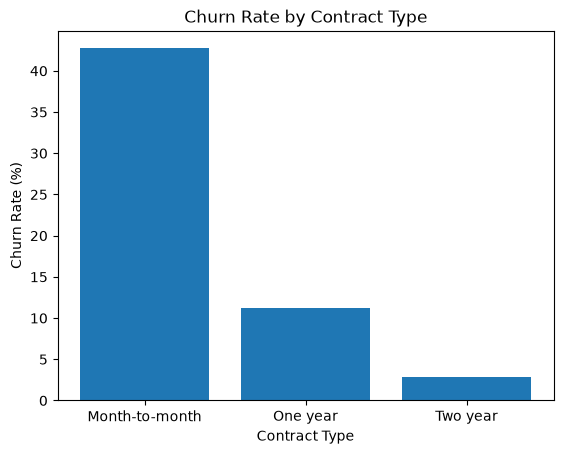

In [98]:
plt.bar(churn_by_contract.index,churn_by_contract.values)
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Contract Type")

In [99]:
data['tenure_group']=pd.cut(data['tenure'],bins=[0, 12, 24, 48, 72],labels=["0-12", "13-24", "25-48", "49-72"])

In [100]:
churn_by_tenure = (
    data.groupby("tenure_group", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(churn_by_tenure)

tenure_group
0-12     47.678161
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: Churn, dtype: float64


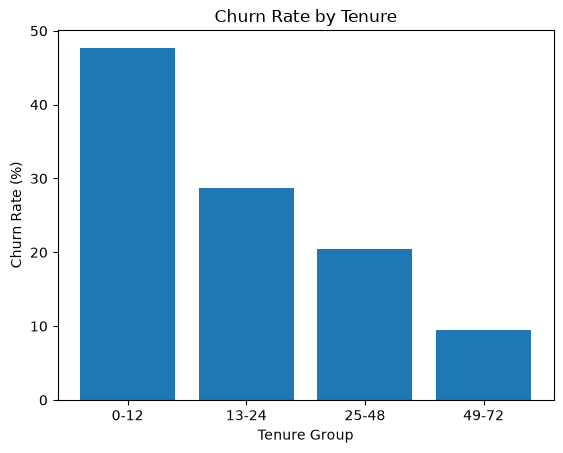

In [101]:
plt.bar(churn_by_tenure.index, churn_by_tenure.values)

plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Tenure")

plt.show()

In [102]:
data.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

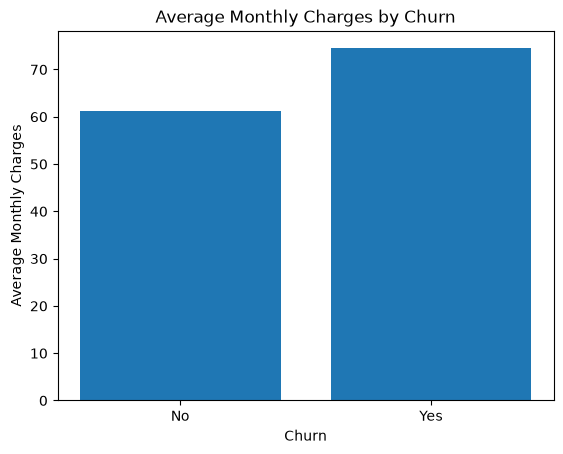

In [103]:
avg_charges = data.groupby("Churn")["MonthlyCharges"].mean()

plt.bar(avg_charges.index, avg_charges.values)

plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.title("Average Monthly Charges by Churn")

plt.show()

In [104]:
data.groupby("Churn")["TotalCharges"].mean()

Churn
No     2549.911442
Yes    1531.796094
Name: TotalCharges, dtype: float64

In [105]:
data.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [106]:
data.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True)*100

SeniorCitizen  Churn
0              No       76.393832
               Yes      23.606168
1              No       58.318739
               Yes      41.681261
Name: proportion, dtype: float64

In [107]:
data.groupby('InternetService')['Churn'].value_counts(normalize=True)*100

InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.595020
                 Yes       7.404980
Name: proportion, dtype: float64

In [108]:
data.groupby("PaymentMethod")["Churn"].value_counts(normalize=True) * 100

PaymentMethod              Churn
Bank transfer (automatic)  No       83.290155
                           Yes      16.709845
Credit card (automatic)    No       84.756899
                           Yes      15.243101
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.893300
                           Yes      19.106700
Name: proportion, dtype: float64

In [109]:
pd.crosstab(
    data["Contract"],
    data["PaymentMethod"],
    values=(data["Churn"] == "Yes"),
    aggfunc="mean"
) * 100

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,34.125637,32.780847,53.729730,31.578947
One year,9.718670,10.301508,18.443804,6.824926
Two year,3.368794,2.237522,7.738095,0.785340


In [110]:
data.shape

(7043, 22)

In [111]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [112]:
for col in service_columns:
    print(col)
    print(data[col].value_counts())
    print()

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

StreamingTV
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

StreamingMovies
StreamingMovies
No                     2785
Yes                    2732
No internet 

In [113]:
data["service_count"] = (data[service_columns] == "Yes").sum(axis=1)

In [133]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,Churn,tenure_group,service_count,avg_monthly_spend,additional_service_count,is_month_to_month,has_support_service,is_electronic_check
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,29.85,No,0-12,1,29.850000,1,True,0,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,56.95,1889.50,No,25-48,3,55.573529,2,False,1,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,53.85,108.15,Yes,0-12,3,54.075000,2,True,1,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,42.30,1840.75,No,25-48,3,40.905556,3,False,1,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,70.70,151.65,Yes,0-12,1,75.825000,0,True,0,1


In [115]:
import numpy as np

In [116]:
data["avg_monthly_spend"]=np.where(data["tenure"]==0,0,data["TotalCharges"]/data["tenure"])

In [118]:
data["avg_monthly_spend"].isna().sum()

np.int64(0)

In [119]:
additional_services=['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

In [120]:
data["additional_service_count"] = (data[additional_services] == "Yes").sum(axis=1)

In [122]:
data["is_month_to_month"] = (
    data["Contract"] == "Month-to-month"
)

In [124]:
support_services = ["OnlineSecurity", "TechSupport"]

In [125]:
data["has_support_service"] = np.where(
    (data[support_services] == "Yes").sum(axis=1) > 0,
    1,
    0
)

In [127]:
data[[
    "service_count",
    "avg_monthly_spend",
    "additional_service_count",
    "is_month_to_month",
    "has_support_service"
]].head(10)

,service_count,avg_monthly_spend,additional_service_count,is_month_to_month,has_support_service
0,1,29.850000,1,True,0
1,3,55.573529,2,False,1
2,3,54.075000,2,True,1
3,3,40.905556,3,False,1
4,1,75.825000,0,True,0
5,5,102.562500,3,True,0
6,4,88.609091,2,True,0
7,1,30.190000,1,True,1
8,6,108.787500,4,True,1
9,3,56.257258,2,False,1


In [128]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'tenure_group', 'service_count', 'avg_monthly_spend',
       'additional_service_count', 'is_month_to_month', 'has_support_service'],
      dtype='str')

In [131]:
data.groupby("PaymentMethod")["Churn"].value_counts(normalize=True)*100

PaymentMethod              Churn
Bank transfer (automatic)  No       83.290155
                           Yes      16.709845
Credit card (automatic)    No       84.756899
                           Yes      15.243101
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.893300
                           Yes      19.106700
Name: proportion, dtype: float64

In [132]:
data["is_electronic_check"] = np.where(
    data["PaymentMethod"] == "Electronic check",
    1,
    0
)

In [134]:
data["is_fiber_optic"] = np.where(
    data["InternetService"] == "Fiber optic",
    1,
    0
)